In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Resume.csv")


In [ ]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
df.shape

(2484, 4)

In [ ]:
df.tail()

,ID,Resume_str,Resume_html,Category
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2483,37473139,STOREKEEPER II Professional Sum...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [ ]:
df.describe()

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


EXPLORATORY DATA ANALYSIS

In [ ]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [ ]:
df["Category"].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


In [ ]:
df.isnull()

,ID,Resume_str,Resume_html,Category
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
2479,False,False,False,False
2480,False,False,False,False
2481,False,False,False,False
2482,False,False,False,False


In [ ]:
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [ ]:
print(df['Resume_str'][0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

In [ ]:
####Drop low sample categories as they can affect the model accuracy negatively

In [ ]:
df=df[~df['Category'].isin(["BPO",'AUTOMOBILE',"AGRICULTURE"])]

df["Category"].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
FINANCE,118
CHEF,118
ACCOUNTANT,118
ENGINEERING,118
FITNESS,117
AVIATION,117


In [ ]:
df.shape

(2363, 4)

In [ ]:
df=df.drop("ID",axis=1)
#### axis=1 means column
#### axis=0 means row


In [ ]:
df=df.drop("Resume_html", axis=1)

KeyError: "['Resume_html'] not found in axis"

In [ ]:
df.shape
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


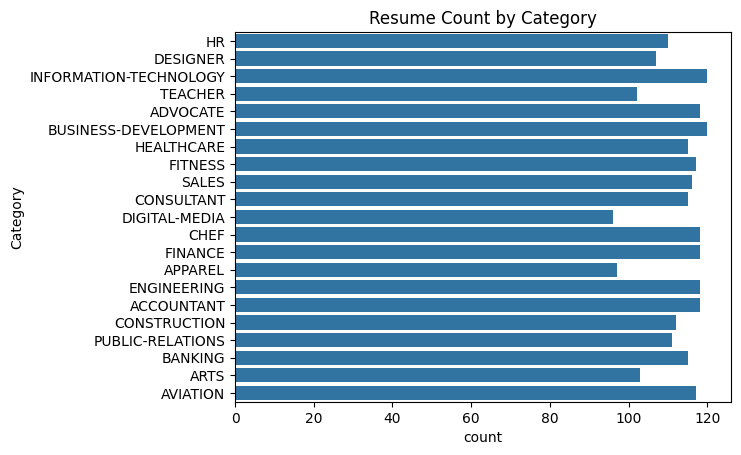

In [ ]:
import seaborn as sns
sns.countplot(y="Category",data=df)
plt.title("Resume Count by Category")
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df=df.drop_duplicates()

In [ ]:
import nltk
import string
nltk.download("stopwords")
from nltk.corpus import stopwords

def clean_text(text):
  text=text.lower()
  text=text.translate(str.maketrans('','',string.punctuation))

  #remove stopwords
  stop_words=set(stopwords.words("english"))
  words=text.split()
  cleaned_words=[]
  for w in words:
    if w not in stop_words:
      cleaned_words.append(w)
  return " ".join(cleaned_words)


  ####Apply to entire datatset
df["cleaned_resume"]=df["Resume_str"].apply(clean_text)
print(df["cleaned_resume"][0])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


hr administratormarketing associate hr administrator summary dedicated customer service manager 15 years experience hospitality customer service management respected builder leader customerfocused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfaction team management marketing savvy conflict resolution techniques training development skilled multitasker client relations specialist accomplishments missouri dot supervisor training certification certified ihg customer loyalty marketing segment hilton worldwide general manager training certification accomplished trainer cross server hospitality systems hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses seminars customer service sales strategies inventory control loss prevention safety time management leadership performance assessment experience hr administratormarketing associate hr administrator dec 2013 current company name － city state helps 

In [ ]:
####TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

vectorizer=TfidfVectorizer(max_features=7000, ngram_range=(1,2))
####ngram_range(1,2) captures single words AND two words phrases
#### only keep the top 7000 most important/frequent words and ignore the rest
X=vectorizer.fit_transform(df["cleaned_resume"])
y=df["Category"]


In [ ]:
####Train-test split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Size ", X_train.shape)
print("Testing Size ",X_test.shape)

Training Size  (1888, 7000)
Testing Size  (473, 7000)


In [ ]:
#### Model Training

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score,f1_score

####Logistic Regression
model_lr=LogisticRegression(max_iter=1000)
model_lr.fit(X_train,y_train)
y_pred_lr=model_lr.predict(X_test)
print("Logistic Regression Accuracy ", accuracy_score(y_test,y_pred_lr))


####Random Forest
model_rf=RandomForestClassifier(n_estimators=100,random_state=42)
model_rf.fit(X_train,y_train)
y_pred_rf=model_rf.predict(X_test)
print("Random Forest Accuracy ", accuracy_score(y_test,y_pred_rf))


####MultiNomialNB
model_nb=MultinomialNB()
model_nb.fit(X_train,y_train)
y_pred_nb=model_nb.predict(X_test)
print("Naive Bayes Accuracy ", accuracy_score(y_test,y_pred_nb))


####GaussianNB- works for continuous numbers
####MultinomialNB is designed specifically for TF-IDF values -freqquency

Logistic Regression Accuracy  0.6701902748414377
Random Forest Accuracy  0.7610993657505285
Naive Bayes Accuracy  0.5665961945031712


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.71      0.94      0.81        31
              ADVOCATE       0.84      0.78      0.81        27
               APPAREL       0.83      0.45      0.59        22
                  ARTS       1.00      0.20      0.33        20
              AVIATION       0.81      0.91      0.86        23
               BANKING       0.69      0.61      0.65        18
  BUSINESS-DEVELOPMENT       0.80      0.92      0.86        26
                  CHEF       0.74      0.81      0.77        21
          CONSTRUCTION       0.87      0.93      0.90        14
            CONSULTANT       0.76      0.59      0.67        27
              DESIGNER       0.73      0.92      0.81        24
         DIGITAL-MEDIA       0.80      0.47      0.59        17
           ENGINEERING       0.86      0.95      0.90        19
               FINANCE       0.90      0.68      0.78        28
  

In [ ]:
####GridSearchCV

from sklearn.model_selection import GridSearchCV
param_grid={
    'n_estimators':[100,200],
    'max_depth':[10,20,30],
    "min_samples_split":[2,5]
}
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print("Tuned Accuracy of Random Forest Classifier ",accuracy_score(y_test,y_pred_tuned))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Accuracy of Random Forest Classifier  0.7420718816067653


In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'RF Tuned'],  # 4 items
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_tuned)  # 4 items
    ]
})
print(results.sort_values('Accuracy', ascending=False))

                 Model  Accuracy
1        Random Forest  0.761099
3             RF Tuned  0.742072
0  Logistic Regression  0.670190
2          Naive Bayes  0.566596


In [ ]:
import joblib
joblib.dump(model_rf, 'resume_model.pkl')
joblib.dump(vectorizer, 'tfidf.pkl')

['tfidf.pkl']

In [ ]:
import os
print(os.path.exists('resume_model.pkl'))
print(os.path.exists('tfidf.pkl'))

True
True


## Conclusion

### Problem Statement
Classified resumes into 24 job categories using NLP and Machine Learning.

### What We Did
- Loaded 2400+ resumes across 24 job categories
- Removed duplicate resumes
- Dropped low sample categories (BPO, Automobile, Agriculture)
- Cleaned text using nltk (lowercase, punctuation removal, stopwords)
- Converted text to numbers using TF-IDF (7000 features, bigrams)
- Trained and compared 3 models
- Applied GridSearchCV for hyperparameter tuning

### Results
| Model | Accuracy |
|---|---|
| Random Forest | 76.1% |
| Logistic Regression | 67.0% |
| Naive Bayes | 56.6% |
| RF Tuned | 74.2% |

### Final Model
Random Forest with default parameters — 76.1% accuracy across 24 categories.
18x better than random guessing (4%).

### Key Finding
GridSearchCV confirmed default parameters were already optimal.
TF-IDF with 7000 features and bigrams gave best results.